# Análise de Sentimentos em Avaliações de Produtos
## Módulo 1 - Mestrado

**Filme:** O Agente Secreto (IMDB)  
**Classificação ternária:** Negativo (1-4), Neutro (5-6), Positivo (7-10)

In [18]:
%pip install pandas numpy matplotlib scikit-learn seaborn requests bs4 lxml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Carregamento e Exploração dos Dados

In [19]:
df = pd.read_csv('reviews_tt27847051.csv')
print(f"Total de reviews: {len(df)}")
print(f"Reviews com rating: {df['rating'].notna().sum()}")
print(f"Reviews com texto: {(df['text'].str.len() > 0).sum()}")
df.head()

Total de reviews: 224
Reviews com rating: 218
Reviews com texto: 224


,rating,title,text,date,author
0,6.0,Interesting but Looooooooooong,I love the story/plot & the look & feel of the...,2026-03-14,maltesefalcon
1,3.0,Just not good,I have Brazilian connections and am fairly fam...,2026-03-14,Heiura
2,8.0,Realistic,If this has something to do with a secret agen...,2026-03-13,justahunch-70549
3,1.0,Extremely boring!,1 hoje of movie and anyhtng that convinced me ...,2026-03-13,LucasP-891
4,9.0,It feels so real.,There's a certain thrill involved with the unc...,2026-03-12,H4wke


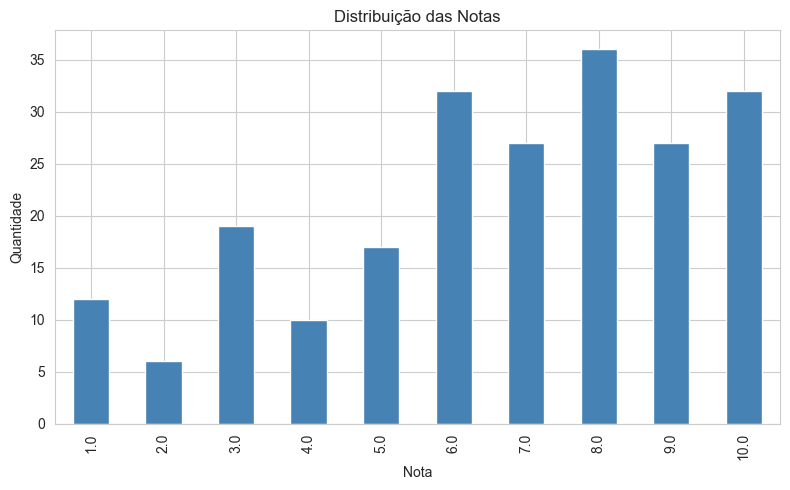

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
df['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Nota')
ax.set_ylabel('Quantidade')
ax.set_title('Distribuição das Notas')
plt.tight_layout()
plt.show()

## 2. Pré-processamento

**Esquema de labels (ternário):**
- **Negativo:** notas 1-4
- **Neutro:** notas 5-6
- **Positivo:** notas 7-10

Distribuição dos sentimentos:
sentiment
Positivo    122
Neutro       49
Negativo     47
Name: count, dtype: int64

Total: 218 reviews


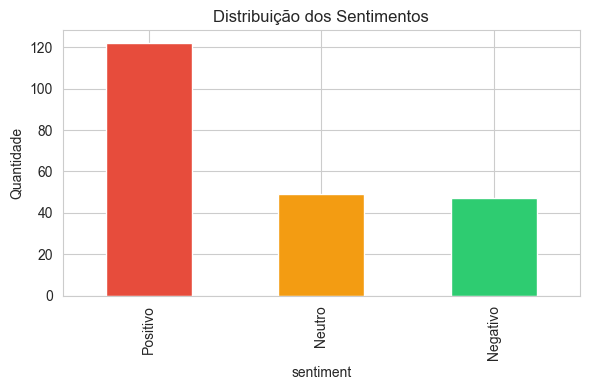

In [21]:
# Remover reviews sem rating
df = df[df['rating'].notna()].copy()

# Atribuir labels
def assign_label(rating):
    if rating <= 4:
        return 'Negativo'
    elif rating <= 6:
        return 'Neutro'
    else:
        return 'Positivo'

df['sentiment'] = df['rating'].apply(assign_label)

print("Distribuição dos sentimentos:")
print(df['sentiment'].value_counts())
print(f"\nTotal: {len(df)} reviews")

fig, ax = plt.subplots(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Distribuição dos Sentimentos')
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.show()

In [22]:
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-záàâãéèêíïóôõöúüçñ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['text_clean'] = df['text'].apply(preprocess_text)

print("Exemplo de texto original:")
print(df['text'].iloc[0][:200])
print("\nTexto pré-processado:")
print(df['text_clean'].iloc[0][:200])

Exemplo de texto original:
I love the story/plot & the look & feel of the movie but i really wish directors would cut scenes that do NOT move the plot & characters forward. Dump the leg in park scene & the german scene. No one 

Texto pré-processado:
love story plot look feel movie really wish directors would cut scenes move plot characters forward dump leg park scene german scene one director would miss dang could really tightened movie made grea


In [23]:
X = df['text_clean']
y = df['sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTreino: {len(X_train)} | Teste: {len(X_test)}")
print(f"Distribuição treino: {np.bincount(y_train)}")
print(f"Distribuição teste:  {np.bincount(y_test)}")

Classes: ['Negativo' 'Neutro' 'Positivo']

Treino: 174 | Teste: 44
Distribuição treino: [38 39 97]
Distribuição teste:  [ 9 10 25]


## 3. Classificador 1: SVM + Bag of Words (TF-IDF)

In [24]:
# Vetorização TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# SVM
svm_bow = SVC(kernel='linear', C=1.0, random_state=42)
svm_bow.fit(X_train_tfidf, y_train)

y_pred_bow = svm_bow.predict(X_test_tfidf)

print("=== SVM + TF-IDF (Bag of Words) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_bow):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_bow, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_bow, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_bow, target_names=le.classes_))

=== SVM + TF-IDF (Bag of Words) ===
Acurácia: 0.6818
F1 (macro): 0.4934
F1 (weighted): 0.5986

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.67      0.67      0.67         9
      Neutro       0.00      0.00      0.00        10
    Positivo       0.71      0.96      0.81        25

    accuracy                           0.68        44
   macro avg       0.46      0.54      0.49        44
weighted avg       0.54      0.68      0.60        44



## 4. Classificador 2: SVM + Embeddings (Sentence-BERT)

In [25]:
%pip install sentence-transformers

from sentence_transformers import SentenceTransformer

# Usar sentence-transformers para gerar embeddings
model_emb = SentenceTransformer('all-MiniLM-L6-v2')

# Embeddings sobre o texto original (não pré-processado) para melhor representação semântica
print("Gerando embeddings...")
X_train_emb = model_emb.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb = model_emb.encode(X_test.tolist(), show_progress_bar=True)
print(f"Shape embeddings: {X_train_emb.shape}")


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6616.53it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando embeddings...


Batches: 100%|██████████| 2/2 [00:00<00:00,  5.99it/s]

Shape embeddings: (174, 384)


In [26]:
# SVM sobre embeddings
svm_emb = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_emb.fit(X_train_emb, y_train)

y_pred_emb = svm_emb.predict(X_test_emb)

print("=== SVM + Sentence Embeddings ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_emb):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_emb, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_emb, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_emb, target_names=le.classes_))

=== SVM + Sentence Embeddings ===
Acurácia: 0.6364
F1 (macro): 0.4317
F1 (weighted): 0.5420

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.67      0.44      0.53         9
      Neutro       0.00      0.00      0.00        10
    Positivo       0.63      0.96      0.76        25

    accuracy                           0.64        44
   macro avg       0.43      0.47      0.43        44
weighted avg       0.50      0.64      0.54        44



## 5. Classificador 3: BERT (Fine-tuning)

In [27]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
num_labels = len(le.classes_)

train_dataset = ReviewDataset(X_train.values, y_train, tokenizer)
test_dataset = ReviewDataset(X_test.values, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Device: cpu
Train batches: 22, Test batches: 6


In [28]:
# Fine-tuning BERT
model_bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
model_bert = model_bert.to(device)

optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5, weight_decay=0.01)
epochs = 10
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

for epoch in range(epochs):
    model_bert.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

# Avaliação
model_bert.eval()
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

y_pred_bert = np.array(all_preds)

print("\n=== BERT Fine-tuned ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_bert):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_bert, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_bert, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_bert, target_names=le.classes_))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7976.93it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

Epoch 1/10 - Loss: 1.0377
Epoch 2/10 - Loss: 0.9546
Epoch 3/10 - Loss: 0.8284
Epoch 4/10 - Loss: 0.7049
Epoch 5/10 - Loss: 0.5914
Epoch 6/10 - Loss: 0.4658
Epoch 7/10 - Loss: 0.3624
Epoch 8/10 - Loss: 0.3171
Epoch 9/10 - Loss: 0.2619
Epoch 10/10 - Loss: 0.2509

=== BERT Fine-tuned ===
Acurácia: 0.7045
F1 (macro): 0.6124
F1 (weighted): 0.6866

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.67      0.89      0.76         9
      Neutro       0.29      0.20      0.24        10
    Positivo       0.84      0.84      0.84        25

    accuracy                           0.70        44
   macro avg       0.60      0.64      0.61        44
weighted avg       0.68      0.70      0.69        44



## 6. Comparação dos Modelos

          Modelo  Acurácia  F1 (macro)  F1 (weighted)
    SVM + TF-IDF  0.681818    0.493409       0.598613
SVM + Embeddings  0.636364    0.431746       0.541991
            BERT  0.704545    0.612400       0.686593


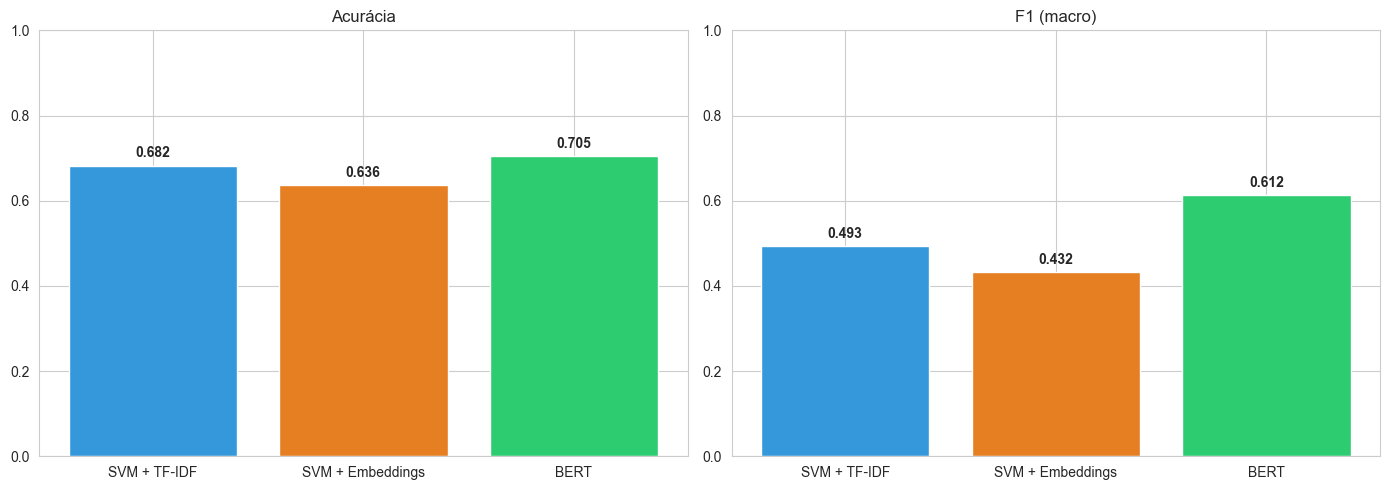

In [29]:
results = pd.DataFrame({
    'Modelo': ['SVM + TF-IDF', 'SVM + Embeddings', 'BERT'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_bow),
        accuracy_score(y_test, y_pred_emb),
        accuracy_score(y_test, y_pred_bert)
    ],
    'F1 (macro)': [
        f1_score(y_test, y_pred_bow, average='macro'),
        f1_score(y_test, y_pred_emb, average='macro'),
        f1_score(y_test, y_pred_bert, average='macro')
    ],
    'F1 (weighted)': [
        f1_score(y_test, y_pred_bow, average='weighted'),
        f1_score(y_test, y_pred_emb, average='weighted'),
        f1_score(y_test, y_pred_bert, average='weighted')
    ]
})

print(results.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Acurácia', 'F1 (macro)']
colors = ['#3498db', '#e67e22', '#2ecc71']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results['Modelo'], results[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    for bar, val in zip(bars, results[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                     f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

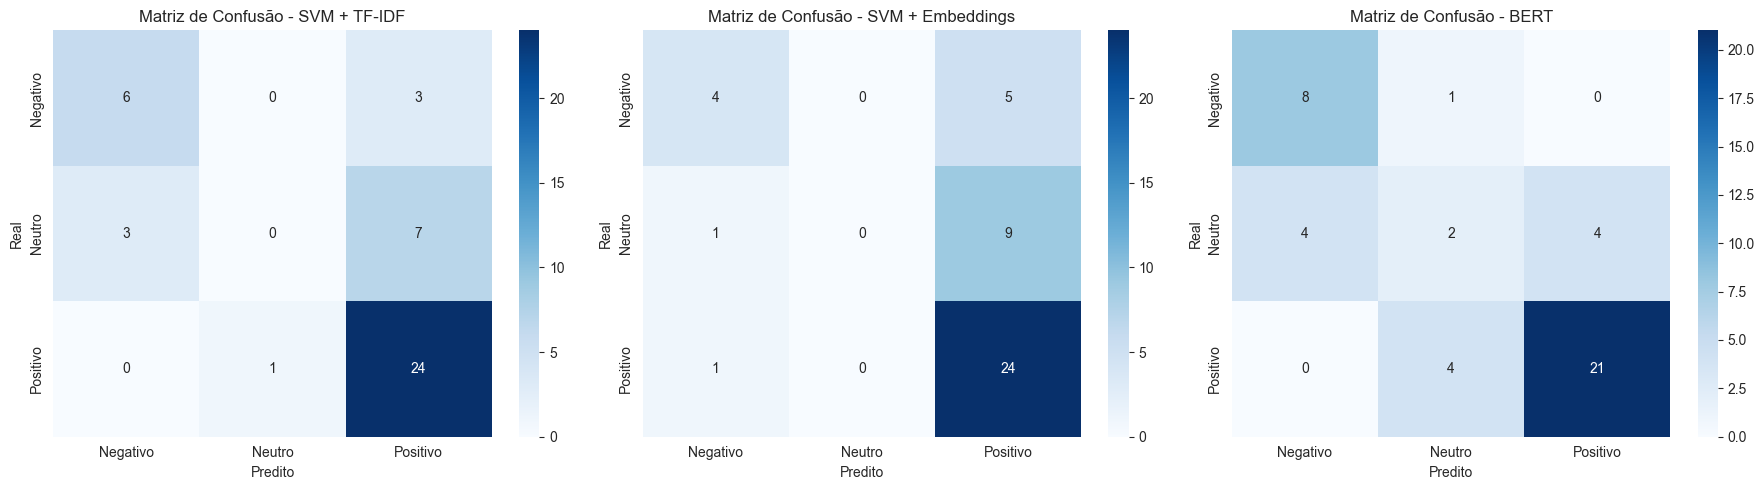

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('SVM + TF-IDF', y_pred_bow),
    ('SVM + Embeddings', y_pred_emb),
    ('BERT', y_pred_bert)
]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'Matriz de Confusão - {name}')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

## 7. Bônus: In-Context Learning

Usando a API da OpenAI/Claude para classificação via few-shot prompting.  
**Nota:** Requer chave de API configurada.

In [ ]:
# In-Context Learning com few-shot prompting
# Simulação usando a estrutura de prompt (substitua pela sua API)

def create_few_shot_prompt(text, examples):
    prompt = """Classifique o sentimento da seguinte avaliação de filme como Negativo, Neutro ou Positivo.

Exemplos:
"""
    for ex in examples:
        prompt += f"Avaliação: \"{ex['text'][:200]}\"\nSentimento: {ex['label']}\n\n"
    
    prompt += f"Avaliação: \"{text[:500]}\"\nSentimento:"
    return prompt

# Selecionar exemplos (2 por classe) para few-shot
examples = []
for label in ['Negativo', 'Neutro', 'Positivo']:
    subset = df[df['sentiment'] == label].head(2)
    for _, row in subset.iterrows():
        examples.append({'text': row['text'], 'label': label})

# Mostrar exemplo de prompt
sample_text = df['text'].iloc[0]
prompt = create_few_shot_prompt(sample_text, examples)
print("=== Exemplo de Prompt Few-Shot ===")
print(prompt[:800])

%pip install -q google-generativeai
import google.generativeai as genai

genai.configure(api_key="***QI")
gemini_model = genai.GenerativeModel('gemini-2.0-flash')

def classify_with_llm(text, examples):
    prompt = create_few_shot_prompt(text, examples)
    response = gemini_model.generate_content(prompt)
    return response.text.strip()

y_pred_icl = []
for text in X_test:
    pred = classify_with_llm(text, examples)
    y_pred_icl.append(le.transform([pred])[0] if pred in le.classes_ else -1)


=== Exemplo de Prompt Few-Shot ===
Classifique o sentimento da seguinte avaliação de filme como Negativo, Neutro ou Positivo.

Exemplos:
Avaliação: "I have Brazilian connections and am fairly familiar with Brazilian film and television. . Wagner Moura's association with this film made me less of a fan, to be honest. Just poorly portrayed and tryin"
Sentimento: Negativo

Avaliação: "1 hoje of movie and anyhtng that convinced me to Stay. Brazil has some good movies, but this is a piece os s#1t. It would have had a better intro, more context, another rhythm, but instead, the direct"
Sentimento: Negativo

Avaliação: "I love the story/plot & the look & feel of the movie but i really wish directors would cut scenes that do NOT move the plot & characters forward. Dump the leg in park scene & the german scene. No one "
Sentimento: 

[Para executar com Gemini, configure sua API key e descomente o código abaixo]

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, ru

In [33]:

from sklearn.metrics import classification_report, accuracy_score

# Filtrar amostras com predições válidas (-1 significa que o LLM retornou label desconhecido)
valid_mask = [p != -1 for p in y_pred_icl]
y_test_valid = [y_test[i] for i, v in enumerate(valid_mask) if v]
y_pred_valid = [y_pred_icl[i] for i, v in enumerate(valid_mask) if v]

print("=== Resultado do LLM (In-Context Learning / Few-Shot) ===\n")
print(f"Total amostras: {len(y_test)}")
print(f"Predições válidas: {len(y_pred_valid)}")
print(f"Predições inválidas (label não reconhecido): {sum(1 for p in y_pred_icl if p == -1)}\n")

if y_pred_valid:
    print(f"Acurácia: {accuracy_score(y_test_valid, y_pred_valid):.4f}\n")
    print("Relatório de Classificação:")
    print(classification_report(y_test_valid, y_pred_valid, target_names=le.classes_))
else:
    print("Nenhuma predição válida para avaliar.")


=== Resultado do LLM (In-Context Learning / Few-Shot) ===

Total amostras: 44
Predições válidas: 44
Predições inválidas (label não reconhecido): 0

Acurácia: 0.7273

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.50      1.00      0.67         9
      Neutro       0.50      0.20      0.29        10
    Positivo       0.95      0.84      0.89        25

    accuracy                           0.73        44
   macro avg       0.65      0.68      0.62        44
weighted avg       0.76      0.73      0.71        44

